# Прикладные задачи анализа данных

## Домашнее задание 4

В этой работе мы будем решать задачу рекомендаций музыки. Для этого мы реализуем метод коллаборативной фильтрации и модель со скрытыми переменными, сравним их между собой и попытаемся сделать выводы. Во всех заданиях разрешается переписывать код по своему усмотрению, предложенные шаблоны несут лишь рекомендательный характер.

In [3]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs
import warnings
warnings.filterwarnings('ignore')

In [4]:
ratings = pd.read_csv('music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [5]:
tracks_info = pd.read_csv('tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


Для оценки качества рекомендаций мы будем использовать метрику $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


*   $N$ - количество пользователей.
*   $n_u$ - число релевантных треков пользователя $u$ на тестовом промежутке.
*   $r_u(i)$ - бинарная величина: относится ли трек на позиции $i$ к релевантным.

**Задание 1 (1 балл).** Реализуйте метрику $MAP@k$.

In [6]:
def mapk(relevant: List[List[int]], predicted: List[List[int]], k: int = 20):
    mapk = 0
    for rel, pred in zip(relevant, predicted):
        rel = np.asarray(rel)
        pred = np.asarray(pred)
        apk = 0
        topk = min(len(rel), k)
        for i in range(k):
            if pred[i] in rel:
                prec = np.isin(pred[:i + 1], rel).sum() / (i + 1)
                apk += prec / topk
        mapk += apk
    mapk = mapk / len(relevant)
    return mapk


In [7]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

Разделим данные на тренировочные и тестовые так, чтобы в теcтовый датасет попали 50 последних треков каждого пользователя.

In [8]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    # getting train samples
    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings += [user_data[:-num_test_samples]]

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # getting train samples
    # we drop all tracks that are not presented it the training samples,
    # because we won't be able to learn representations for them
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [9]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Почистим табличку с информацией о треках и закодируем id треков так, чтобы они соответствовали их порядковому номеру.

In [10]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [11]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [12]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

In [13]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [14]:
test_ratings.head()

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168


Соберем все релевантные треки для каждого пользователя в список.

In [15]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

**Задание 2 (1 балл).** Реализуйте метод `get_test_recommendations` в классе `BaseModel`. Он принимает на вход параметр `k` и возвращает массив из `k` наиболее подходящих треков для каждого пользователя. Не забывайте удалять уже прослушанные треки из рекомендуемых.

In [16]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.

    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []

        for user_id in range(self.n_users):
            pred = self.recommend(user_id)
            test_preds.append(pred)

        test_preds = self.remove_train_items(test_preds, k)

        return test_preds[test_users]

## Часть 1. Коллаборативная фильтрация (User2User)

Идея: чтобы выбрать треки, которые понравятся пользователю, можно набрать несколько похожих на него пользователей (соседей) и посмотреть, какие треки они слушают. После этого остается агрегировать треки этих пользователей и выбрать самые популярные. Соответственно, задача состоит из двух частей: выбора функции похожести двух пользователей и способа агрегации.

В качестве функции похожести мы будем использовать две метрики:

1. Корреляция Пирсона $$s(u, v) = \frac{\sum_{i \in I_u \cap I_v} r_{ui}r_{vi}}{\sqrt{\sum_{i \in I_u} r_{ui} ^2}\sqrt{\sum_{i \in I_v} r_{vi}^2}} $$

2. Мера Жаккара

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$


Корреляция Пирсона немного видоизменена, чтобы подходить под нашу задачу.


Во всех формулах
* $I_u$ - множество треков, прослушанных пользователем $u$.
* $r_{ui}$ - прослушал ли пользователь $u$ трек $i$ (0 или 1).

Множество соседей определим как $$N(u) = \{ v \in U \setminus \{u\} \mid s(u, v) > \alpha\},$$ где $\alpha \, - $ гиперпараметр.



Для агрегации мы будем пользоваться следующей формулой.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

**Задание 3.1 (1 балл).** Реализуйте функцию подсчета корреляции Пирсона.

**Задание 3.2 (1 балл).** Реализуйте функцию подсчета меры Жаккара.

Функции принимают матрицу оценок и вектор оценок пользователя $u$ и возвращают вектор со значениями похожести пользователя $u$ на всех пользователей. Старайтесь писать оптимизированный код, за неэффективную реализацию оценка может быть снижена.

In [17]:
def pearson(ratings: np.array, user_vector: np.array) -> np.array:
    chisl = np.dot(ratings, user_vector)
    znam = np.sqrt(user_vector.sum() * ratings.sum(axis=1))
    return chisl / znam


def jaccard(ratings: np.array, user_vector: np.array) -> np.array:
    chisl = np.dot(ratings, user_vector)
    znam = ((((ratings + user_vector) - 1) >= 0) * 1).sum(axis=1)
    return chisl / znam

**Задание 4 (1 балл).** Реализуйте методы `similarity` и `recommend` класса `User2User`. `recommend` возвращает индексы треков, отсортированные в порядке убывания предсказанных оценок.


In [18]:
class User2User(BaseModel):
    def __init__(self, ratings, similarity_func):
        super().__init__(ratings)

        assert similarity_func in [pearson, jaccard]

        self.similarity_func = similarity_func
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """
        return self.similarity_func(self.R, user_vector)


    def recommend(self, uid: int):
        user_vector = self.R[uid]
        sim_users = self.similarity(user_vector)
        mask = sim_users > self.alpha
        sim_users = sim_users * mask
        sim_users[uid] = 0
        chisl = np.dot(sim_users, self.R)
        znam = np.sum(np.abs(sim_users))
        aggr = chisl / znam
        rec = self.ratings['trackId'][aggr.argsort()[::-1]]
        return rec


**Задание 5 (1 балл).** Постройте графики зависимости значений $MAP@k$ от разных $k$ для обоих функций похожести, сравните их между собой, а также с предсказаниями случайного алгоритма и сделайте выводы.

In [19]:
np.random.seed(42)
k_values = [1, 5, 10, 15, 20, 30, 40, 60]
mapk_pearson, mapk_jaccard, mapk_random = [], [], []
for k in k_values:
    User2User_pearson = User2User(train_ratings, pearson)
    User2User_jaccard = User2User(train_ratings, jaccard)
    songs = train_ratings['trackId'].unique()
    random_alg = []
    for i in range(len(test_users)):
        random_alg.append(np.random.choice(songs, size=k, replace=False).tolist())
    mapk_pearson.append(mapk(test_relevant, User2User_pearson.get_test_recommendations(k), k))
    mapk_jaccard.append(mapk(test_relevant, User2User_jaccard.get_test_recommendations(k), k))
    mapk_random.append(mapk(test_relevant, random_alg, k))

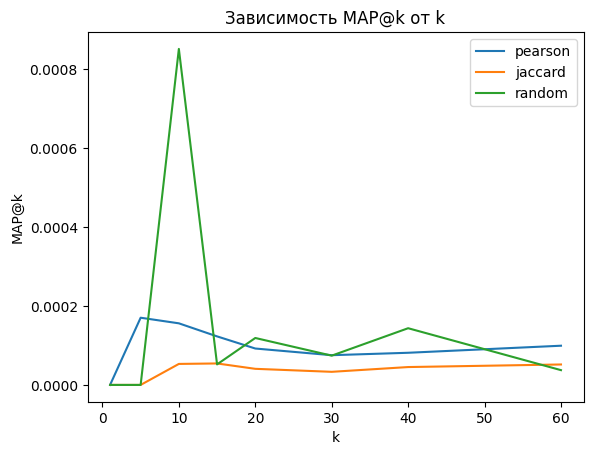

In [20]:
plt.plot(k_values, mapk_pearson, label='pearson')
plt.plot(k_values, mapk_jaccard, label='jaccard')
plt.plot(k_values, mapk_random, label='random')
plt.legend()
plt.title('Зависимость MAP@k от k')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.show()

**Вывод**: Корреляция Пирсона даёт более качественные рекомендации по сравнению с Жакаром, особенно на малых k, где важна точность первых рекомендаций. Мера Жакара - слишком упрощённая метрика, не учитывающая силу связи между пользователями. Случайный алгоритм показывает нестабильные результаты. Единственный пик на k=10 - случайность, дальше — затухание. Но в среднем он как будто предсказывает лучше других.

Однако в целом алогритмы справляются очень плохо - значение метрики менее 0.1%


Мы можем посмотреть глазами, насколько хорошо модель рекомендует треки. Для этого сравним уже прослушанные треки с рекомендованными и релевантными для случайного пользователя. Хорошо ли у вас получилось?

In [22]:
user_id = np.random.randint(0, User2User_pearson.n_users)

In [23]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
69,Cry For You,['September']
97,Heads Will Roll,['Yeah Yeah Yeahs']
98,The Wizard,['Black Sabbath']
220,I Was Made For Lovin' You,['Kiss']
234,Wind Of Change,['Scorpions']
292,Livin' On A Prayer,['Bon Jovi']
293,You Give Love A Bad Name,['Bon Jovi']
300,All Star,['Smash Mouth']
303,I'm A Believer,['Smash Mouth']
746,Behind Blue Eyes,['Limp Bizkit']


In [24]:
preds = User2User_pearson.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

Predicted tracks:


,name,artists
10920,Troublemaker,['Taio Cruz']
40014,Only You,['The Platters']
19829,Freaks,"['Timmy Trumpet', 'Savage']"
24850,Собирай меня,['Артём Пивоваров']
22147,Bitch I'm Madonna,"['Madonna', 'Nicki Minaj']"
21198,Celebrate,['Pitbull']
11889,What Is Love?,['Haddaway']
29236,Unholy Gravebirth,['Infant Annihilator']
24983,When I Needed You,['Carly Rae Jepsen']
27969,This Girl (Kungs Vs Cookin' On 3 Burners),"['Kungs', ""Cookin' On 3 Burners""]"


In [27]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
63174,gorit,['DOROFEEVA']
63327,My Head & My Heart,['Ava Max']
63443,Flashbacks,['INNA']
63611,Bubble Gum,['TRITICUM']
63776,White Lies,"['VIZE', 'Tokio Hotel']"
63777,Friday,"['Riton', 'Nightcrawlers', 'Mufasa & Hypeman']"
63888,Wasted Love,"['Ofenbach', 'Lagique']"
63901,Astronaut In The Ocean,['Masked Wolf']
63928,Your Love (9PM),"['ATB', 'Topic', 'A7S']"
63937,Too Much Of Heaven Luis Rodriguez Remix,"['Eiffel 65', 'Luis Rodriguez']"
